In [1]:
import os
import shutil
import random
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


In [2]:
src = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
dst = "/kaggle/working/plant_dataset"
train_dir = os.path.join(dst, "train")
val_dir = os.path.join(dst, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

classes = [cls for cls in os.listdir(src) if os.path.isdir(os.path.join(src, cls))]

for cls in tqdm(classes, desc="Organizing dataset"):
    src_cls_path = os.path.join(src, cls)
    imgs = [f for f in os.listdir(src_cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    random.shuffle(imgs)

    split = int(0.8 * len(imgs))
    train_imgs, val_imgs = imgs[:split], imgs[split:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy2(os.path.join(src_cls_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy2(os.path.join(src_cls_path, img), os.path.join(val_dir, cls, img))


Organizing dataset: 100%|██████████| 38/38 [08:40<00:00, 13.70s/it]


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
print(f"Using {n_gpu} GPU(s)")

model = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=len(train_data.classes))

if n_gpu > 1:
    model = nn.DataParallel(model)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2, verbose=True)


Using 2 GPU(s)


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_losses, label="Train Loss", color='blue', marker='o')
    plt.plot(epochs, val_losses, label="Val Loss", color='red', marker='o')
    plt.title("Training and Validation Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_accuracies, label="Train Accuracy", color='blue', marker='o')
    plt.plot(epochs, val_accuracies, label="Val Accuracy", color='red', marker='o')
    plt.title("Training and Validation Accuracy Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
train_losses_list = []
val_losses_list = []
train_acc_list = []
val_acc_list = []

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
patience = 4
counter = 0

for epoch in range(20):
    print(f"\n🌀 Epoch {epoch+1}")

    model.train()
    train_loss = 0.0
    train_correct = 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_data)
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_correct = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_data)
    avg_val_loss = val_loss / len(val_loader)

    train_losses_list.append(avg_train_loss)
    val_losses_list.append(avg_val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"🔁 Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"✅ Val   Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "/kaggle/working/best_vit_model.pth")
        print("💾 Best model saved!")
        counter = 0
    else:
        counter += 1
        print(f"⏳ Early stop patience: {counter}/{patience}")
        if counter >= patience:
            print("🛑 Early stopping triggered.")
            break

    scheduler.step(avg_val_loss)



🌀 Epoch 1


Validation: 100%|██████████| 220/220 [00:52<00:00,  4.23it/s]


🔁 Train Loss: 0.1724, Acc: 0.9568
✅ Val   Loss: 0.0331, Acc: 0.9911
💾 Best model saved!

🌀 Epoch 2


Validation: 100%|██████████| 220/220 [00:51<00:00,  4.26it/s]


🔁 Train Loss: 0.0310, Acc: 0.9906
✅ Val   Loss: 0.0521, Acc: 0.9847
⏳ Early stop patience: 1/4

🌀 Epoch 3


...

🔁 Train Loss: 0.0002, Acc: 1.0000
✅ Val   Loss: 0.0044, Acc: 0.9989
💾 Best model saved!

🌀 Epoch 19


Validation: 100%|██████████| 220/220 [00:52<00:00,  4.21it/s]


🔁 Train Loss: 0.0002, Acc: 0.9999
✅ Val   Loss: 0.0040, Acc: 0.9990
💾 Best model saved!

🌀 Epoch 20


Validation: 100%|██████████| 220/220 [00:51<00:00,  4.24it/s]

🔁 Train Loss: 0.0002, Acc: 1.0000
✅ Val   Loss: 0.0044, Acc: 0.9987
⏳ Early stop patience: 1/4


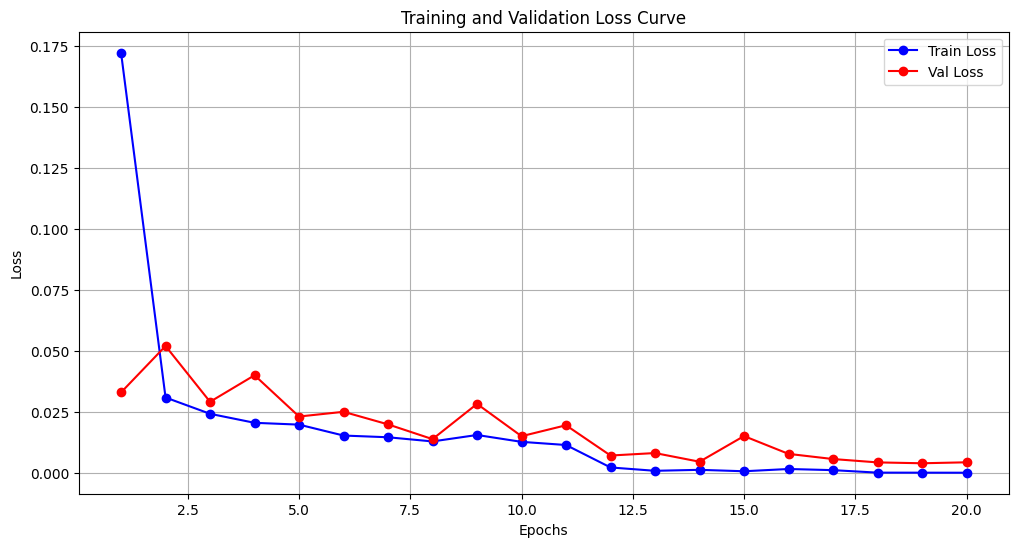

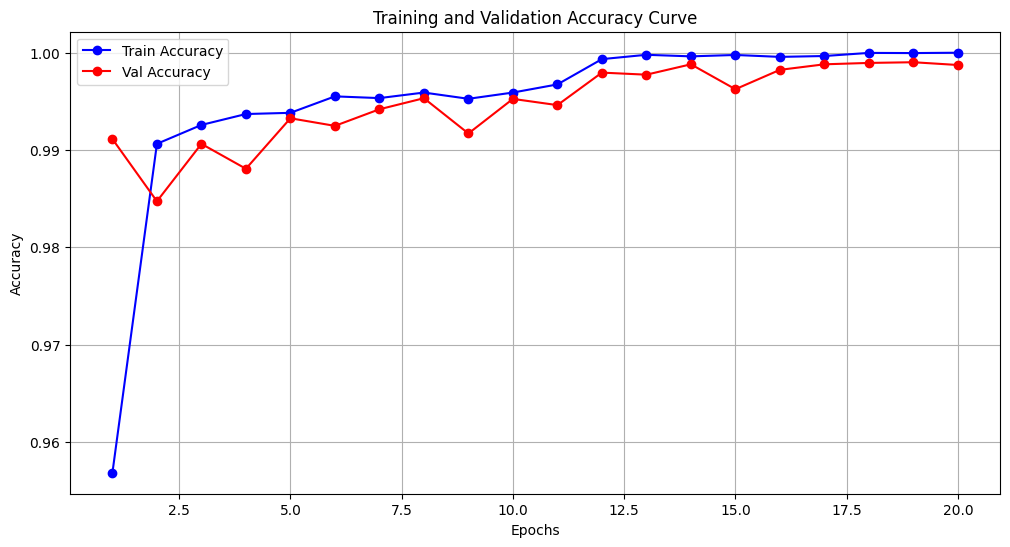

In [7]:
plot_metrics(train_losses_list, val_losses_list, train_acc_list, val_acc_list)


/tmp/ipykernel_19/839259037.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/working/best_vit_model.pth"))
Evaluating: 100%|████


Confusion Matrix:
[[404   0   0 ...   0   0   0]
 [  0 398   0 ...   0   0   0]
 [  0   0 352 ...   0   0   0]
 ...
 [  0   0   0 ... 393   0   0]
 [  0   0   0 ...   0 358   0]
 [  0   0   0 ...   0   0 385]]


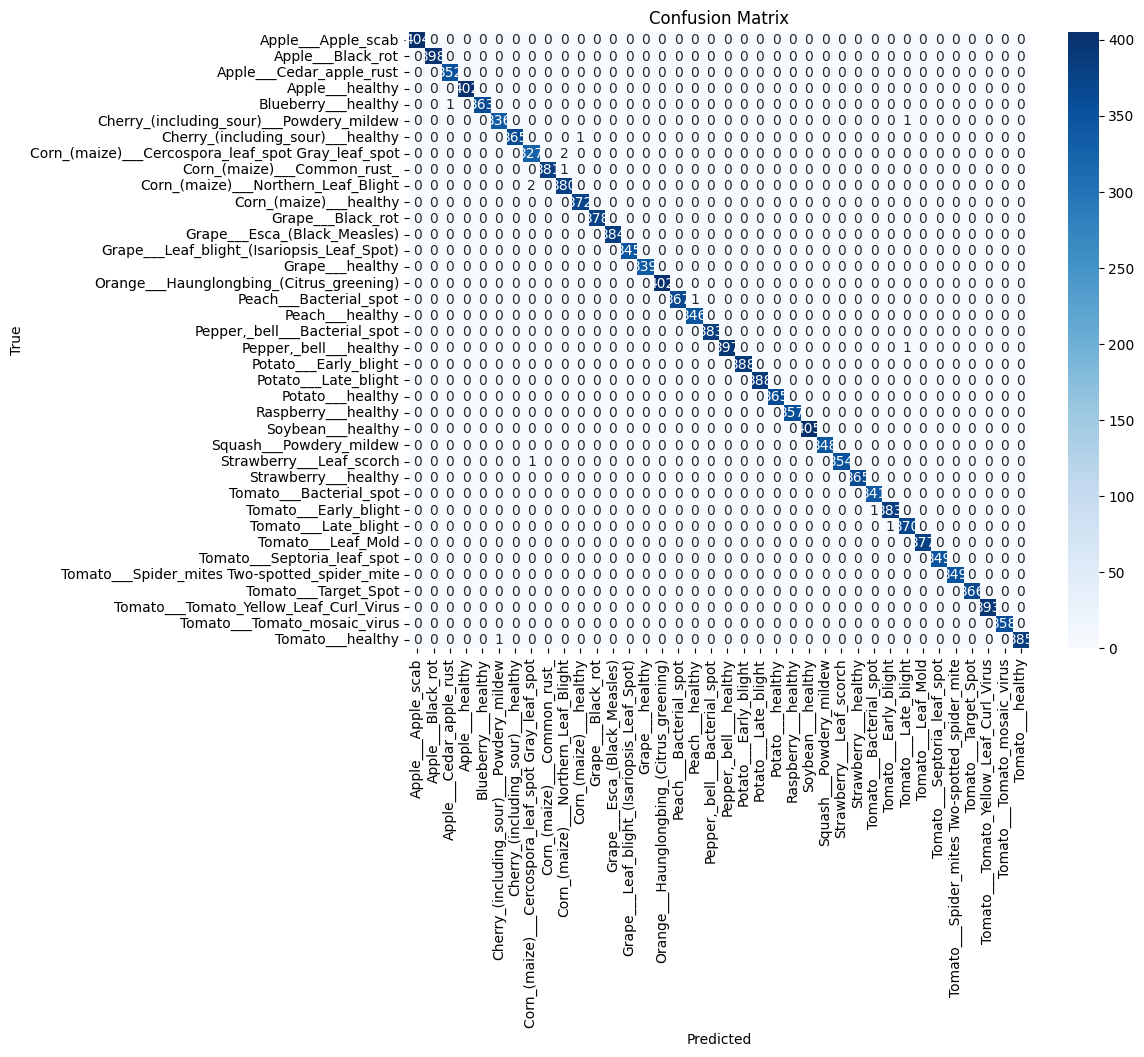


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       404
                                 Apple___Black_rot       1.00      1.00      1.00       398
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       352
                                   Apple___healthy       1.00      1.00      1.00       402
                               Blueberry___healthy       1.00      1.00      1.00       364
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       337
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       366
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.99      0.99      0.99       329
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       382
               Corn_(maize)___Northern_Leaf_Blight     

In [8]:
model.load_state_dict(torch.load("/kaggle/working/best_vit_model.pth"))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))
